In [1]:
#Imports 
import rasterio
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier,early_stopping, log_evaluation
import numpy as np

## Importing data:

In [2]:
back = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/backscatter.tif")
bath = rasterio.open("/kaggle/input/competitions/geohab-mlwg-competition-2026/MBES/bathymetry.tif")
train_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/geohab-mlwg-competition-2026/test.csv')

In [3]:
print('Train set: ', train_df.shape)
display(train_df.head())

print('Test set: ', test_df.shape)
display(test_df.head())

back_data = back.read(1)
print('Backscatter data: ',back_data.shape)
print(back_data[:5, :5])

bath_data = bath.read(1)
print('Bathymestry data: ', bath_data.shape)
print(bath_data[:5, :5])

Train set:  (6256, 3)


,class,x,y
0,NVB,453594.477237,5.679192e+06
1,FMAT,453561.906453,5.679109e+06
2,ALG,453744.452238,5.679033e+06
3,ALG,453863.445302,5.679038e+06
4,ALG,453964.611906,5.679017e+06


Test set:  (98, 3)


,ID,x,y
0,1,453702.166779,5.679044e+06
1,2,454126.252800,5.678999e+06
2,3,453957.881092,5.678942e+06
3,4,453798.917484,5.678955e+06
4,5,453520.953671,5.679124e+06


Backscatter data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]
Bathymestry data:  (4040, 4743)
[[-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]
 [-10000. -10000. -10000. -10000. -10000.]]


## Extracting Features:

### Grid feature

In [4]:
def get_neighborhood_features(x, y):
    row, col = bath.index(x, y)
    
    features = []
    
    for dr in [-12, 0, 12]:
        for dc in [-12, 0, 12]:
            r = row + dr
            c = col + dc
            
            try:
                depth = bath_data[r, c]
                scatter = back_data[r, c]
            except:
                depth = 0
                scatter = 0
            
            features.append(depth)
            features.append(scatter)
    
    return features

In [5]:
features = train_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

train_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

train_df[train_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [6]:
print(train_feature_cols)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17']


In [7]:
train_df.head()

,class,x,y,f0,f1,f2,f3,f4,f5,f6,...,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17
0,NVB,453594.477237,5.679192e+06,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-10000.000000,-2.667833,...,-2.822883,-18.669088,-3.003832,-16.779381,-3.052902,-17.719353,-3.153770,-18.979156,-3.217835,-21.499985
1,FMAT,453561.906453,5.679109e+06,-5.861867,-24.649494,-5.705794,-19.609058,-5.636959,-19.928892,-5.808707,...,-5.668992,-20.558794,-5.697957,-22.129887,-6.120852,-20.558794,-5.797802,-21.189917,-6.232965,-21.189917
2,ALG,453744.452238,5.679033e+06,-9.233783,-24.339426,-8.520893,-24.019592,-8.426841,-24.339426,-9.579664,...,-9.288988,-23.389690,-9.054879,-23.709524,-9.672694,-27.169104,-10.006989,-21.189917,-10.029820,-23.709524
3,ALG,453863.445302,5.679038e+06,-6.856915,-24.339426,-6.731852,-24.339426,-6.698797,-25.599232,-7.546973,...,-7.263793,-21.189917,-6.937677,-22.449720,-8.047904,-19.609058,-7.883994,-18.039186,-7.642729,-21.819818
4,ALG,453964.611906,5.679017e+06,-8.769996,-24.339426,-7.727922,-20.238960,-7.976172,-24.649494,-9.685985,...,-9.784807,-22.449720,-8.631302,-28.749962,-10.117740,-25.599232,-10.628894,-27.169104,-10.871862,-27.488937


### Advanced feature engineering:

In [8]:
def get_advanced_features(x, y):
    row, col = bath.index(x, y)
    
    depths = []
    scatters = []
    
    for dr in [-10, 0, 10]:
        for dc in [-10, 0, 10]:
            r = row + dr
            c = col + dc
            
            if 0 <= r < bath_data.shape[0] and 0 <= c < bath_data.shape[1]:
                depths.append(bath_data[r, c])
                scatters.append(back_data[r, c])
            else:
                depths.append(0)
                scatters.append(0)
    
    return [
        np.mean(depths),
        np.std(depths),
        np.min(depths),
        np.max(depths),
        np.mean(scatters),
        np.std(scatters),
        np.min(scatters),
        np.max(scatters),
    ]

In [9]:
features = train_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

adv_feature_cols = [
    'depth_mean', 'depth_std', 'depth_min', 'depth_max',
    'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max'
]

train_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=train_df.index)

In [10]:
print(adv_feature_cols)

['depth_mean', 'depth_std', 'depth_min', 'depth_max', 'scatter_mean', 'scatter_std', 'scatter_min', 'scatter_max']


## Model:

In [11]:
target = 'class'

X = train_df[train_feature_cols + adv_feature_cols]
y = train_df[target].map({'SGAM': 0, 'NVB': 1, 'SGZ': 2, 'ALG': 3, 'FMAT': 4})

#splitting the data into train/val splits
X_train , X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

In [12]:
lgb_params = {
   'n_estimators': 1879,
 	'learning_rate': 0.0765079139135192,
 	'num_leaves': 57,
 	'max_depth': 13,
 	'min_child_samples': 23,
 	'subsample': 0.9491400225657889,
 	'colsample_bytree': 0.6671968380388436,
	'reg_alpha': 0.002067039466798589,
 	'reg_lambda': 0.004458960681919556,
    "random_state": 42,
    "device": "gpu",
    "n_jobs": -1,
    "verbose": -1,
    # 'class_weight': 'balanced'
}

In [13]:
model = LGBMClassifier(**lgb_params)
model.fit(X_train,y_train)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LGBMClassifier(colsample_bytree=0.6671968380388436, device='gpu',
               learning_rate=0.0765079139135192, max_depth=13,
               min_child_samples=23, n_estimators=1879, n_jobs=-1,
               num_leaves=57, random_state=42, reg_alpha=0.002067039466798589,
               reg_lambda=0.004458960681919556, subsample=0.9491400225657889,
               verbose=-1)

In [14]:
val_preds = model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='weighted')

print('Validation accuracy LGBM: ', val_acc)
print('Validation f1 LGBM: ', val_f1)

Validation accuracy LGBM:  0.9528753993610224
Validation f1 LGBM:  0.9526798276136268


## Feature Importance

In [15]:
import lightgbm as lgbm
import matplotlib.pyplot as plt

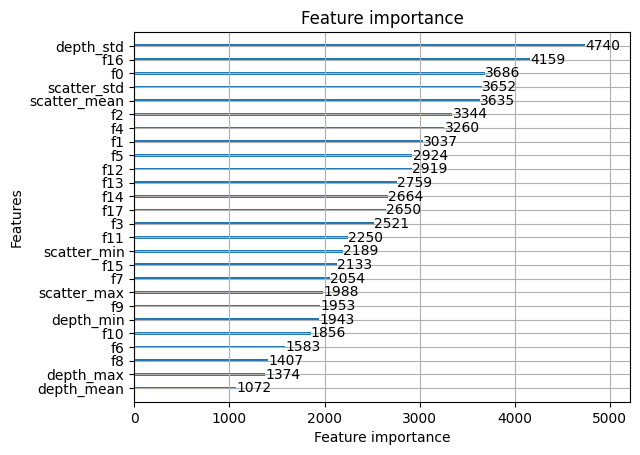

In [16]:
lgbm.plot_importance(model, max_num_features=30)
plt.show()

In [17]:
features = train_feature_cols + adv_feature_cols
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values()

print(importance)

depth_mean      1072
depth_max       1374
f8              1407
f6              1583
f10             1856
depth_min       1943
f9              1953
scatter_max     1988
f7              2054
f15             2133
scatter_min     2189
f11             2250
f3              2521
f17             2650
f14             2664
f13             2759
f12             2919
f5              2924
f1              3037
f4              3260
f2              3344
scatter_mean    3635
scatter_std     3652
f0              3686
f16             4159
depth_std       4740
dtype: int32


## OOF preds

In [18]:
features = test_df.apply(
    lambda r: get_neighborhood_features(r['x'], r['y']),
    axis=1
)

test_feature_cols = [f'f{i}' for i in range(len(features.iloc[0]))]

test_df[test_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [19]:
features = test_df.apply(
    lambda r: get_advanced_features(r['x'], r['y']),
    axis=1
)

test_df[adv_feature_cols] = pd.DataFrame(features.tolist(), index=test_df.index)

In [20]:
X_test = test_df[test_feature_cols + adv_feature_cols]

## Seed averaging

In [21]:
# seeds = [42, 52, 62, 72, 82] 
seeds = [52, 62, 72] # seeds catching whole variance

In [22]:
# Hyperparameters found via Optuna
best_params = {
    "n_estimators": 2000,
    "learning_rate": 0.07918500203202344,
    "max_depth": 11,
    "num_leaves": 77,
    "subsample": 0.8055152296793877,
    "colsample_bytree": 0.7103689169741864,
    "reg_alpha": 0.014069050212386091,
    "reg_lambda": 0.7078441464734376,
    "min_child_samples": 9,
    "class_weight": "balanced",
    "random_state": 42,
    "device": "gpu",
    "n_jobs": -1,
    "verbose": -1,
}

n_classes = len(np.unique(y))
final_test_probs = np.zeros((len(X_test), n_classes))

seed_scores = []

for seed in seeds:
    
    print(f"\n===== Seed {seed} =====")
    
    best_params["random_state"] = seed
    
    oof_preds = np.zeros(len(X), dtype=int)
    test_probs = np.zeros((len(X_test), n_classes))
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        model = LGBMClassifier(**best_params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[early_stopping(50, verbose=False),log_evaluation(0)]
        )

        # Validation predictions
        val_preds = model.predict(X_va)
        oof_preds[val_idx] = val_preds

        # Fold weighted F1
        fold_f1 = f1_score(y_va, val_preds, average="weighted")
        fold_scores.append(fold_f1)

        print(f"Fold {fold} Weighted F1: {fold_f1:.5f}")

        # Test predictions
        test_probs += model.predict_proba(X_test) / skf.n_splits

    # Seed OOF score
    seed_f1 = f1_score(y, oof_preds, average="weighted")
    seed_scores.append(seed_f1)

    print(f"Seed {seed} OOF Weighted F1: {seed_f1:.5f}")
    print(f"Seed {seed} Fold Avg F1: {np.mean(fold_scores):.5f}")

    final_test_probs += test_probs / len(seeds)

# Overall average across seeds
print("\n==============================")
print("Seed Scores:", [round(s, 5) for s in seed_scores])
print(f"Overall Avg Weighted F1: {np.mean(seed_scores):.5f}")
print("==============================")

# Final predictions
final_test_preds = np.argmax(final_test_probs, axis=1)


===== Seed 52 =====
Fold 1 Weighted F1: 0.94899
Fold 2 Weighted F1: 0.95362
Fold 3 Weighted F1: 0.94184
Fold 4 Weighted F1: 0.94643
Fold 5 Weighted F1: 0.95127
Seed 52 OOF Weighted F1: 0.94841
Seed 52 Fold Avg F1: 0.94843

===== Seed 62 =====
Fold 1 Weighted F1: 0.94814
Fold 2 Weighted F1: 0.95364
Fold 3 Weighted F1: 0.94259
Fold 4 Weighted F1: 0.94886
Fold 5 Weighted F1: 0.94656
Seed 62 OOF Weighted F1: 0.94795
Seed 62 Fold Avg F1: 0.94796

===== Seed 72 =====
Fold 1 Weighted F1: 0.94813
Fold 2 Weighted F1: 0.95444
Fold 3 Weighted F1: 0.93780
Fold 4 Weighted F1: 0.95045
Fold 5 Weighted F1: 0.94801
Seed 72 OOF Weighted F1: 0.94776
Seed 72 Fold Avg F1: 0.94776

Seed Scores: [0.94841, 0.94795, 0.94776]
Overall Avg Weighted F1: 0.94804


In [23]:
classes = np.array(['SGAM', 'NVB', 'SGZ', 'ALG', 'FMAT'])  

final_preds = classes[np.argmax(final_test_probs, axis=1)]

submission = pd.DataFrame({
    'ID': test_df['ID'],
    target: final_preds
})

submission.to_csv('submission_seed_avg.csv', index=False)

In [24]:
print(f'\nSaved: submission_seed_avg.csv')
print(f'Prediction distribution:\n{pd.Series(final_preds).value_counts()}')


Saved: submission_seed_avg.csv
Prediction distribution:
NVB     42
ALG     21
FMAT    19
SGAM     9
SGZ      7
Name: count, dtype: int64


Seed averaging helps initiate model at different random_states which helps us learn different splits and can help gain heigher scores, in our case it seem to have worked as well, next step will be ensembling where we will use this seed averaging model as one of the models in the ensemble.